<a href="https://colab.research.google.com/github/krishnakanthkona-3110/My-DSA-Journey/blob/main/Dynamic_Programming/Dynamic_Programming/DSA_Dynamic_Programming_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://notability.com/n/1YZRHyRRO7hev_ISn4q6zb

# 1Q). Fractional Knapsack

1Q). Given two integer arrays A and B of size N each which represent values and weights associated with N items respectively.

Also given an integer C which represents knapsack capacity.

Find out the maximum total value that we can fit in the knapsack. If the maximum total value is ans, then return ⌊ans × 100⌋ , i.e., floor of (ans × 100).

NOTE:

You can break an item for maximizing the total value of the knapsack

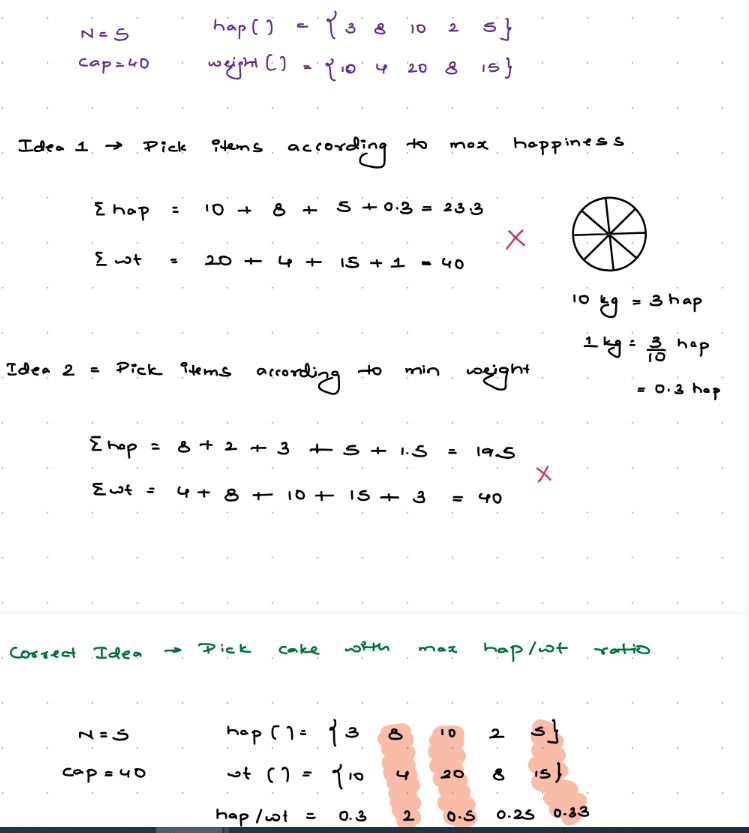

In [ ]:
def frac_snap(v,w,c):

  items = []
  n = len(v)

  # Step 1: create (ratio, value, weight)
  for i in range(n):
    ratio = v[i]/w[i]

    items.append((ratio, v[i],w[i]))

  # Step 2: sort by ratio descending
  items.sort(key = lambda x:x[0],reverse=True)
  # items.sort(reverse=True)

  total_value = 0.0

  # Step 3: pick items
  for ratio, value, weight in items:
    if c >= weight:
      total_value +=  value
      c -= weight
    else:
      total_value += ratio*c
      break

  return total_value

In [ ]:
frac_snap([3,8,10,2,5],[10,4,20,8,15],40)

23.3

1. Creates a list of items with their ratio, value, and weight, which takes O(n) time.
2. Sorts the list of items based on the ratio in descending order, which takes O(n log n) time.
3. Iterates through the sorted list to select items or fractions thereof, which takes O(n) time in the worst case.

Overall time complexity: O(n log n) due to the sorting step, as it dominates the other linear operations.

Space complexity:
- The items list stores n tuples, each containing three elements, so it requires O(n) space.
- Additional variables use constant space.

Overall space complexity: O(n).

# 2Q). 0-1 Knapsack
 Given two integer arrays A and B of size N each which represent values and weights associated with N items respectively.

Also given an integer C which represents knapsack capacity.

Find out the maximum value subset of A such that sum of the weights of this subset is smaller than or equal to C.

NOTE:

You cannot break an item, either pick the complete item, or don’t pick it (0-1 property).

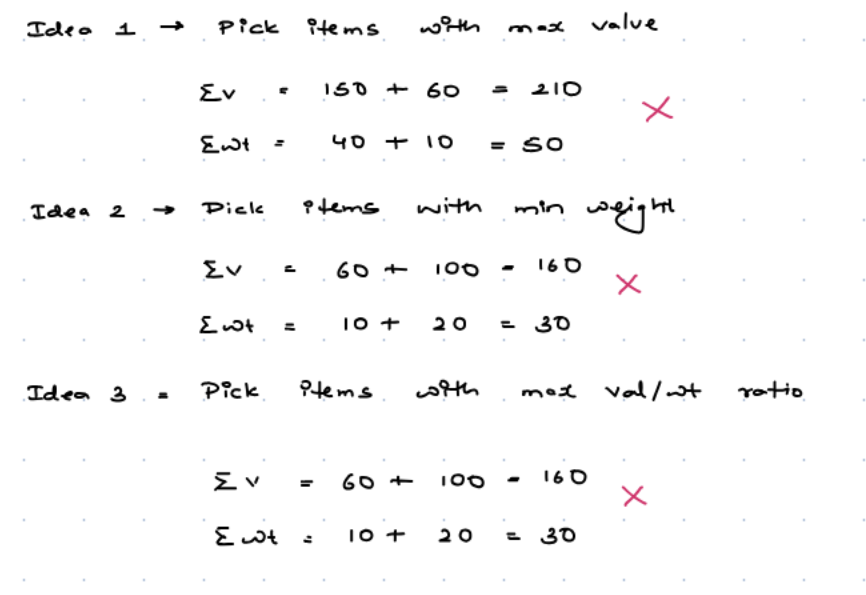

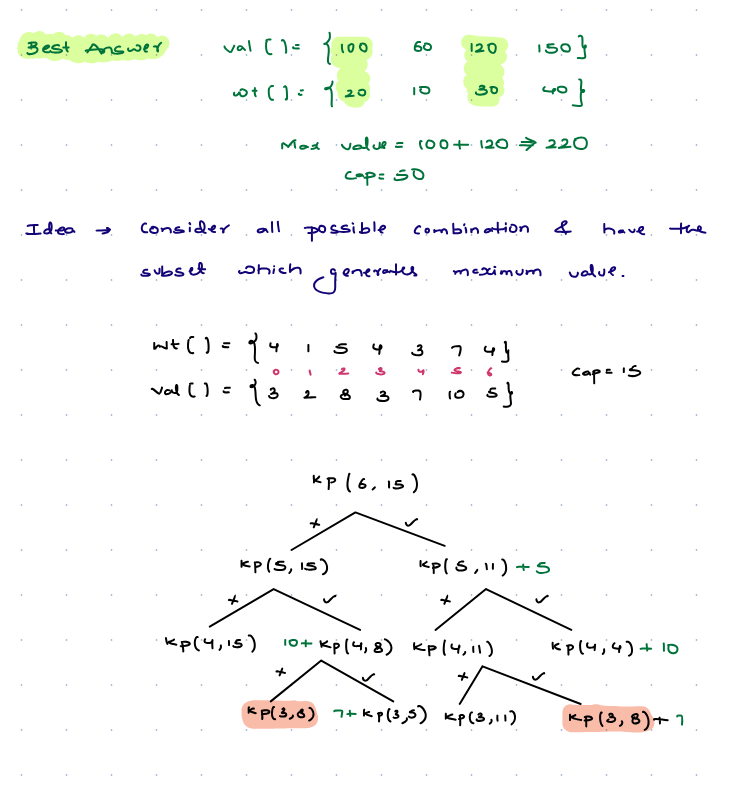

same sub problems, so recursion can be applied

In [ ]:
def knapsack(i, j, wt, val, dp):
    # Base case
    if i < 0 or j == 0:
        return 0

    # Memoization check
    if dp[i][j] != -1:
        return dp[i][j]

    # Not pick
    not_pick = knapsack(i - 1, j, wt, val, dp)

    # Pick
    pick = 0
    if wt[i] <= j:
        pick = knapsack(i - 1, j - wt[i], wt, val, dp) + val[i]

    # Store and return
    dp[i][j] = max(pick, not_pick)
    return dp[i][j]


# Input
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = len(wt)

# DP array
dp = [[-1] * (cap + 1) for _ in range(n)]

# Call function
result = knapsack(n - 1, cap, wt, val, dp)
print(result)   # Output: 21


21


In [ ]:
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = len(wt)

# Create DP table
dp = [[0] * (cap + 1) for _ in range(n + 1)]

# Fill the table
for i in range(1, n + 1):
    for j in range(1, cap + 1):

        # Not pick
        rej = dp[i - 1][j]

        # Pick
        sel = 0
        w = wt[i - 1]
        v = val[i - 1]

        if w <= j:
            sel = dp[i - 1][j - w] + v

        # Take maximum
        dp[i][j] = max(sel, rej)

# Final answer
print(dp[n][cap])   # Output: 21

21


Time Complexity:
- Each state in the DP table is defined by two parameters: the item index (i) and the remaining capacity (j).
- The total number of states is n * (cap + 1), where n is the number of items.
- Each state is computed once and stored in the DP table.
- Therefore, the overall time complexity is O(n * cap).

Space Complexity:
- The DP table requires space proportional to n * (cap + 1), which is O(n * cap).
- Additionally, the recursion stack depth can go up to O(n) in the worst case, but this is generally overshadowed by the DP table space.
- Hence, the total space complexity is O(n * cap).

In summary:
Time complexity: O(n * cap)
Space complexity: O(n * cap)

The time complexity is O(N × capacity) since we fill a DP table of size N × cap, and the space complexity is also O(N × cap), which can be optimized to O(cap) using a 1D DP array

In [ ]:
dp = [0] * (cap + 1)

for i in range(n):
    for j in range(cap, wt[i] - 1, -1):   # 🔥 backward
        dp[j] = max(dp[j], val[i] + dp[j - wt[i]])

In [ ]:
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = 4

In [ ]:
dp[cap]

21

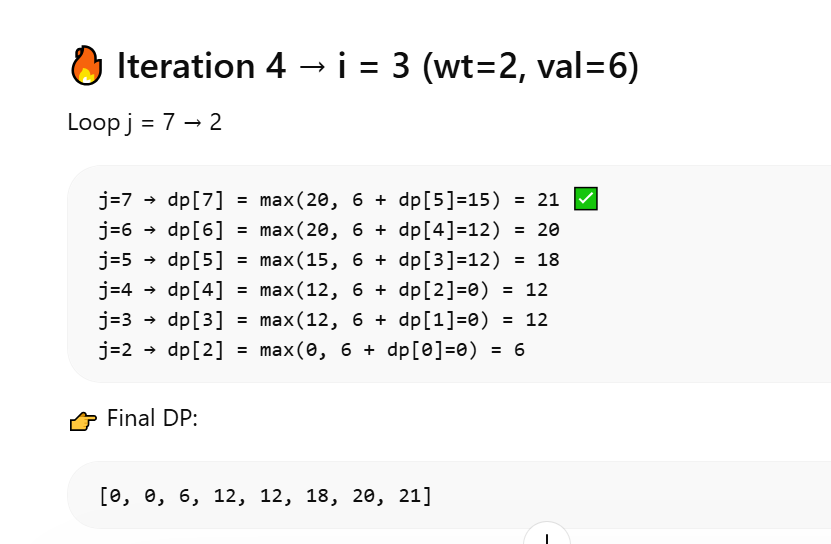

# 3Q). Unbounded knapsack (O-N knapsack)

Given N items each with a weight and value. Find max value which can be obtained by picking items such that total weight of all items <= capacity(k).

Note 1:- Every item can be picked infinite number of times.

Note 2:- We cannot take a part of item.

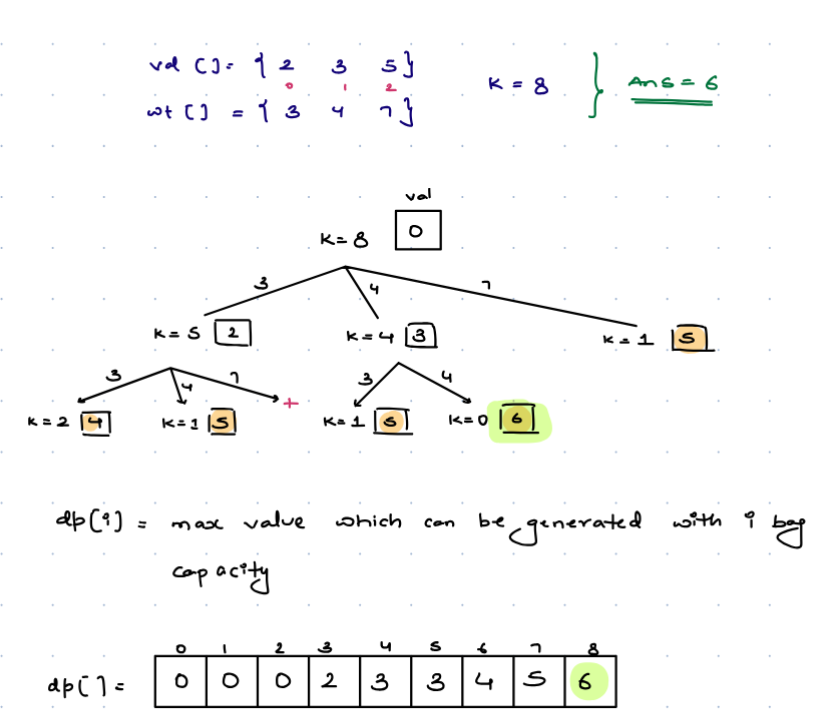

In [8]:
def solve(A, B, C):
    # A -> values of items
    # B -> weights of items
    # C -> capacity of knapsack

    n = len(A)  # number of items

    # dp[i] will store the maximum value we can get with capacity = i
    dp = [0] * (C + 1)

    # Loop through all capacities from 0 to C
    for i in range(C + 1):

        # Try picking every item for this capacity
        for j in range(n):

            # Check if current item can fit into capacity i
            if B[j] <= i:

                # Remaining capacity after taking this item
                remaining_capacity = i - B[j]

                # Value if we take this item:
                # current item's value + best value for remaining capacity
                take = A[j] + dp[remaining_capacity]

                # Value if we don't take this item
                not_take = dp[i]

                # Take the maximum of both choices
                dp[i] = max(not_take, take)

    # Final answer: maximum value for full capacity C
    return dp[C]

In [9]:
A = [10, 40, 50, 70]
B = [1, 3, 4, 5]
C = 8
solve(A,B,C)

110

Time: O(K × N)

Space: O(K)

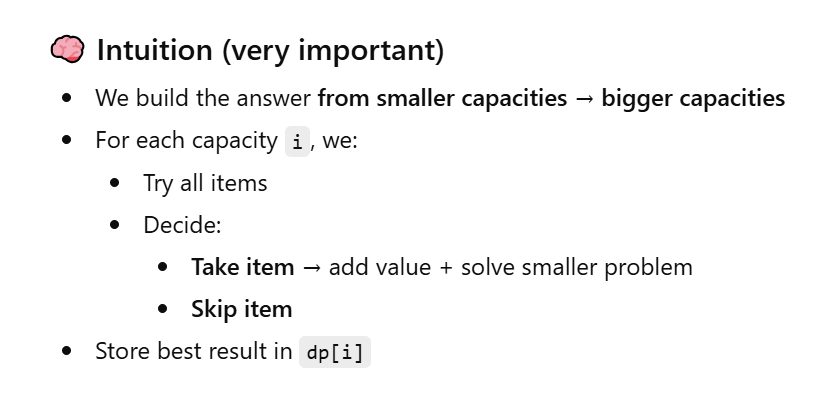

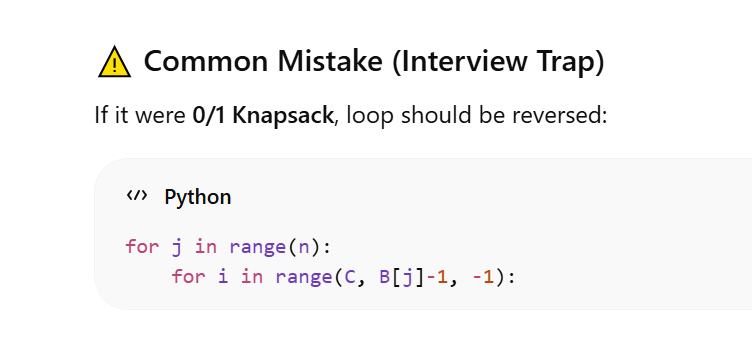

# 4Q). Given a rod of length N and an array of length N+1.

A[i] ---> price of i length rod.

Find the maximum value we can obtain by selling the rod.

In [17]:

def solve_recur(A):
    N = len(A) - 1  # rod length

    # memoization table
    dp = [[-1] * (N + 1) for _ in range(N + 1)]

    def helper(index, length):
        # Base case
        if index == 0:
            return 0

        # If already computed
        if dp[index][length] != -1:
            return dp[index][length]

        # Not take current length
        not_take = helper(index - 1, length)

        # Take current length (only if possible)
        take = 0
        if index <= length:
            # stay at same index (unbounded)
            take = A[index] + helper(index, length - index)

        # Store result
        dp[index][length] = max(take, not_take)
        return dp[index][length]

    return helper(N, N)

In [18]:
solve_recur([2,1,3,4,5])

6

Time complexity: O(N^2)

Space complexity: O(N^2)

In [20]:
def solve(A):
    N = len(A) - 1

    dp = [[0] * (N + 1) for _ in range(N + 1)]

    for i in range(1, N + 1):
        for length in range(1, N + 1):

            not_take = dp[i - 1][length]

            take = 0
            if i <= length:
                take = A[i] + dp[i][length - i]

            dp[i][length] = max(take, not_take)

    return dp[N][N]

In [21]:
A = [2,1,3,4,5]
solve(A)

6

In [24]:
def solve(A):
    # A[i] = price of rod of length i
    # Total rod length = N
    N = len(A) - 1

    # dp[i][length] means:
    # Maximum profit we can get using rod pieces of length up to 'i'
    # to form a rod of total length = 'length'
    dp = [[0] * (N + 1) for _ in range(N + 1)]

    # i -> current rod piece length we are considering (1 to N)
    for i in range(1, N + 1):

        # length -> current target rod length (1 to N)
        for length in range(1, N + 1):

            # ❌ NOT TAKE:
            # Skip current length 'i'
            # Move to smaller lengths (i-1)
            not_take = dp[i - 1][length]

            # ✅ TAKE:
            # Take current rod piece of length 'i'
            take = 0
            if i <= length:
                # Since this is UNBOUNDED:
                # we can reuse same length again → stay at same 'i'

                # Value = price of current piece + value of remaining rod
                take = A[i] + dp[i][length - i]

            # Store the best of both choices
            dp[i][length] = max(take, not_take)

    # Final answer:
    # Maximum profit using all lengths to form rod of size N
    return dp[N][N]

In [25]:
# 1 DP solution

def solve(A):
    # A[i] = price of rod of length i
    N = len(A) - 1

    # dp[i] = maximum profit for rod of length i
    dp = [0] * (N + 1)

    # Build solution for all lengths from 1 to N
    for length in range(1, N + 1):

        # Try all possible cuts j (1 to length)
        for j in range(1, length + 1):

            # Cut a piece of length j
            # Remaining rod = length - j
            # Total value = price[j] + best value of remaining rod
            dp[length] = max(dp[length], A[j] + dp[length - j])

    # Final answer: max profit for rod of full length N
    return dp[N]

In [26]:
A = [2,1,3,4,5]
solve(A)

6

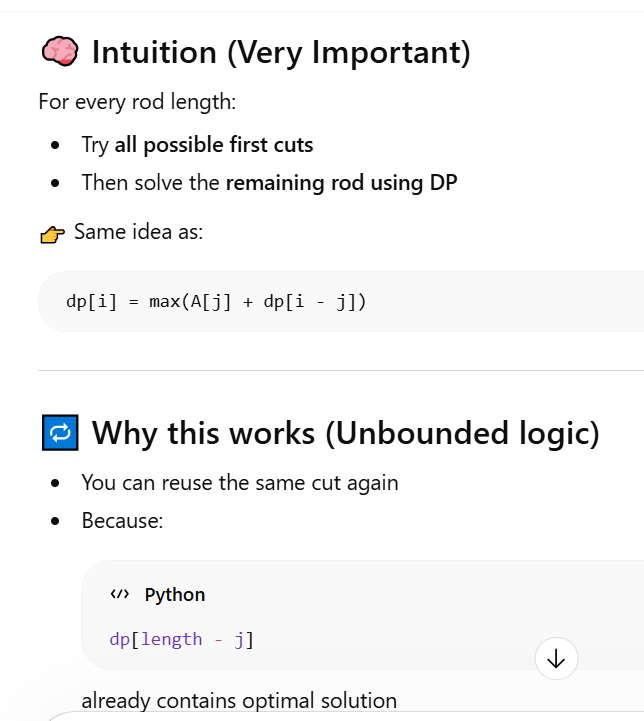

I optimize the 2D DP into 1D by observing that each state depends only on previous lengths. This reduces space from O(N²) to O(N) while keeping time complexity O(N²).”